In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv('CarPrice_Assignment.csv')
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
data=data.drop(['CarName','car_ID'],axis=1)
data=pd.get_dummies(data,drop_first=True)


In [4]:
X=data.drop('price',axis=1)
y=data['price']

In [5]:
scaler=StandardScaler()
X=scaler.fit_transform(X)
y=scaler.fit_transform(np.array(y).reshape(-1,1))

In [6]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
sgd_model=SGDRegressor(max_iter=1000,tol=1e-3)

In [8]:
sgd_model.fit(x_train,y_train)
y_pred=sgd_model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
print('Name:Akila S')
print('Reg No:212225220008')
print(f"{'MSE':}:{mean_squared_error(y_test,y_pred):}")
print(f"{'MAE':}:{mean_absolute_error(y_test,y_pred):}")
print(f"{'R-squared':}:{r2_score(y_test,y_pred):}")

Name:Akila S
Reg No:212225220008
MSE:0.21327332310038635
MAE:0.32133951563980145
R-squared:0.8284216896021928


In [10]:
print("\nModel Coefficients:")
print("Coffecients:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)


Model Coefficients:
Coffecients: [ 0.03420165  0.10663835  0.012873    0.17897515  0.01824723  0.17732126
  0.28797555 -0.01647842 -0.08555219  0.00074874  0.10919437  0.03879484
 -0.0387992  -0.04870594 -0.02158843  0.01884008  0.01880904 -0.01652834
 -0.08739863 -0.01195493 -0.09233398 -0.03334563  0.06084771  0.20939336
  0.01468822 -0.09790913  0.07755903 -0.01761956  0.00143029  0.01081856
 -0.03446735 -0.14540473 -0.06761714  0.00077501 -0.02747648  0.01081856
 -0.00408204 -0.01561644  0.02158843 -0.0186998  -0.03193258 -0.0410015
 -0.01630378]
Intercept: [-0.01107288]


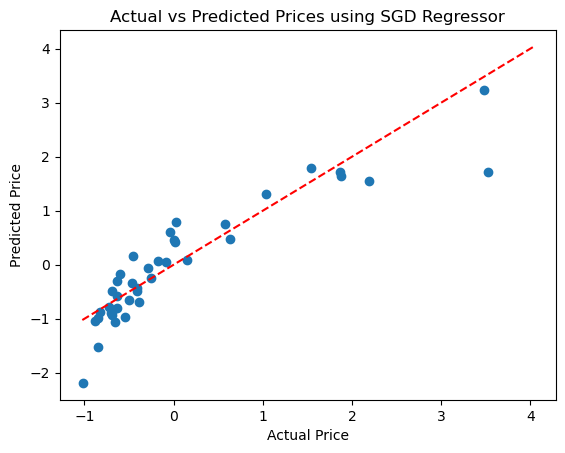

In [11]:
plt.scatter(y_test,y_pred)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()                                                                                                                                                                       